# 🔍 Ruído — DCT + SRM + XGBoost
**Técnica:** Seleção de patches via DCT + extração de ruído via filtros SRM + estatísticas globais Laplacian  
**Modelo:** XGBoost (substitui MLP)  
**Output:** `modelo_ruido.pkl` + `threshold.json`

---

## Bloco 1 — Setup

In [1]:
import os
import random
import json
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
from pathlib import Path
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from PIL import Image, ImageFile, ImageFilter
ImageFile.LOAD_TRUNCATED_IMAGES = True
import cv2
from scipy.ndimage import convolve
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, brier_score_loss
)

print('✅ Imports OK')

✅ Imports OK


In [2]:
# ─── CONFIGURAÇÕES ───────────────────────────────────────────────────────────
DATASET_ROOT = Path(r'C:\Users\JoaoC\OneDrive\Desktop\DSXIZ')
OUTPUT_DIR   = Path('../../modelos/Ruido')
CACHE_DIR    = Path('./cache_ruido')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_REAL = DATASET_ROOT / 'train' / 'real'
TRAIN_FAKE = DATASET_ROOT / 'train' / 'fake'
TEST_REAL  = DATASET_ROOT / 'test'  / 'real'
TEST_FAKE  = DATASET_ROOT / 'test'  / 'fake'

RESIZE_TO  = (256, 256)
PATCH_SIZE = 32
N_PATCHES  = 3
EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

print('✅ Configurações OK')
print(f'   Output: {OUTPUT_DIR.resolve()}')
print(f'   Cache:  {CACHE_DIR.resolve()}')

✅ Configurações OK
   Output: C:\Users\JoaoC\OneDrive\Documentos\Tcc\Xiz9\modelos\Ruido
   Cache:  C:\Users\JoaoC\OneDrive\Documentos\Tcc\Xiz9\modelos_treinamento\ruido\cache_ruido


## Bloco 2 — Filtros SRM e Funções de Extração

In [3]:
# ── Filtros SRM (extração de ruído) ──────────────────────────────────────────
# Baseados no trabalho de Fridrich & Kodovsky (2012)
# Cada filtro captura um padrão de ruído diferente na imagem
SRM_FILTERS = [
    # Filtros originais — direções horizontal, vertical e diagonal
    np.array([[0, 0, 0], [0, -1, 1], [0, 0, 0]], dtype=np.float32),
    np.array([[0, 0, 0], [0, -1, 0], [0, 1, 0]], dtype=np.float32),
    np.array([[0, 0, 0], [0, -2, 1], [0, 1, 0]], dtype=np.float32),
    # Filtros adicionados v2 — capturam variações em outras direções
    np.array([[-1, 2, -1], [0, 0, 0], [0, 0, 0]], dtype=np.float32),
    np.array([[0, 0, 0], [-1, 2, -1], [0, 0, 0]], dtype=np.float32),
    np.array([[-1, 0, 0], [2, 0, 0], [-1, 0, 0]], dtype=np.float32),
    # Filtros adicionados v3 — variações verticais, diagonais e Laplaciano 2D
    np.array([[0, -1, 0], [0, 2, 0], [0, -1, 0]], dtype=np.float32),
    np.array([[-1, 0, 1], [0, 0, 0], [1, 0, -1]], dtype=np.float32),
    np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], dtype=np.float32),
]

print(f'✅ {len(SRM_FILTERS)} filtros SRM carregados')

✅ 9 filtros SRM carregados


In [4]:
print(TRAIN_REAL.resolve())
print(TRAIN_REAL.exists())

C:\Users\JoaoC\OneDrive\Desktop\DSXIZ\train\real
True


In [5]:
def apply_srm(patch: np.ndarray) -> np.ndarray:
    """Aplica filtros SRM no patch e retorna o padrão de ruído.
    Para cada filtro extrai média e desvio padrão — 2 features por filtro.
    """
    results = []
    for f in SRM_FILTERS:
        filtered = convolve(patch.astype(np.float32), f)
        results.append(float(np.mean(np.abs(filtered))))
        results.append(float(np.std(filtered)))
    return np.array(results)


def dct_score(patch: np.ndarray) -> float:
    """Calcula score de frequência do patch via DCT.
    Score alto = alta frequência (bordas, texturas complexas).
    Score baixo = baixa frequência (regiões suaves).
    """
    return float(np.sum(np.abs(cv2.dct(patch.astype(np.float32)))))


def augment_image_bytes(image_bytes: bytes) -> bytes:
    """Augmentation específico para detecção de ruído.
    JPEG mais frequente e agressivo pois recompressão sobrescreve padrões SRM.
    Aplicar SOMENTE no treino — nunca no teste ou validação.
    """
    img = Image.open(BytesIO(image_bytes)).convert('RGB')

    if random.random() < 0.5:
        scale = random.uniform(0.75, 1.25)
        img = img.resize(
            (int(img.width * scale), int(img.height * scale)),
            Image.LANCZOS
        )
    if random.random() < 0.9:
        quality = random.randint(50, 95)
        buf = BytesIO()
        img.save(buf, format='JPEG', quality=quality)
        img = Image.open(BytesIO(buf.getvalue())).convert('RGB')

    if random.random() < 0.2:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.3, 1.0)))

    out = BytesIO()
    img.save(out, format='PNG')
    return out.getvalue()


def extract_features_from_bytes(image_bytes: bytes):
    """Extrai features DCT + SRM + estatísticas globais a partir de bytes.
    Total: 6 patches × 9 filtros × 2 estatísticas + 4 globais = 112 features
    """
    try:
        img = Image.open(BytesIO(image_bytes)).convert('L').resize(RESIZE_TO)
        arr = np.array(img, dtype=np.float32) / 255.0
        h, w = arr.shape

        # ── 1. Seleção de patches via DCT ─────────────────────────────────────
        patches = []
        for y in range(0, h - PATCH_SIZE + 1, PATCH_SIZE):
            for x in range(0, w - PATCH_SIZE + 1, PATCH_SIZE):
                patch = arr[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                patches.append((dct_score(patch), patch))

        if not patches:
            return None

        patches.sort(key=lambda p: p[0])
        selected = [p for _, p in patches[:N_PATCHES]] + [p for _, p in patches[-N_PATCHES:]]

        # ── 2. Extração de ruído via filtros SRM (108 features) ───────────────
        features = []
        for patch in selected:
            features.extend(apply_srm(patch))

        # ── 3. Estatísticas globais do Laplacian (4 features) ─────────────────
        # Imagens reais têm variância alta; imagens de IA tendem a ser mais suaves
        laplacian = cv2.Laplacian((arr * 255).astype(np.uint8), cv2.CV_64F)
        features.extend([
            float(np.var(laplacian)),
            float(np.mean(np.abs(laplacian))),
            float(np.std(laplacian)),
            float(np.percentile(np.abs(laplacian), 90)),
        ])

        result = np.array(features, dtype=np.float32)
        return np.nan_to_num(result, nan=0.0, posinf=0.0, neginf=0.0)

    except Exception:
        return None


# Teste rápido
test_files = [f for f in TRAIN_REAL.rglob('*') if f.suffix.lower() in EXTENSIONS]
sample = extract_features_from_bytes(test_files[0].read_bytes())
print(f'✅ Features extraídas: {len(sample)} dimensões')
print(f'   NaN: {np.isnan(sample).sum()} | Inf: {np.isinf(sample).sum()}')

✅ Features extraídas: 112 dimensões
   NaN: 0 | Inf: 0


## Bloco 3 — Extração do Dataset Completo (com cache)

In [6]:
def list_images(folder: Path):
    return [p for p in folder.rglob('*') if p.suffix.lower() in EXTENSIONS]


def process(args):
    fpath, label, aug = args
    try:
        raw  = fpath.read_bytes()
        feat = extract_features_from_bytes(raw)
        results = []
        if feat is not None:
            results.append((feat, label))
        if aug:
            feat_aug = extract_features_from_bytes(augment_image_bytes(raw))
            if feat_aug is not None:
                results.append((feat_aug, label))
        return results
    except Exception:
        return []


def extract_split(real_folder, fake_folder, prefix, augment=False, n_workers=8):
    cache_X = CACHE_DIR / f'{prefix}_X.npy'
    cache_y = CACHE_DIR / f'{prefix}_y.npy'

    if cache_X.exists() and cache_y.exists():
        print(f'📦 Carregando {prefix} do cache...')
        return np.load(cache_X), np.load(cache_y)

    all_files = ([(f, 0, augment) for f in list_images(real_folder)] +
                 [(f, 1, augment) for f in list_images(fake_folder)])

    aug_str = 'com augmentation' if augment else 'sem augmentation'
    print(f'⚙️  Extraindo {prefix} ({len(all_files):,} imagens, {aug_str})...')

    X, y = [], []
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        for results in tqdm(executor.map(process, all_files),
                            total=len(all_files), desc=prefix):
            for feat, label in results:
                X.append(feat)
                y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int8)
    np.save(cache_X, X)
    np.save(cache_y, y)
    print(f'   ✅ {len(X):,} amostras salvas em cache')
    return X, y


X_train, y_train = extract_split(TRAIN_REAL, TRAIN_FAKE, 'train', augment=True)
X_test,  y_test  = extract_split(TEST_REAL,  TEST_FAKE,  'test',  augment=False)

print(f'\n📐 Train: {X_train.shape} | Test: {X_test.shape}')
print(f'📊 Train — Real: {(y_train==0).sum():,} | Fake: {(y_train==1).sum():,}')
print(f'📊 Test  — Real: {(y_test==0).sum():,}  | Fake: {(y_test==1).sum():,}')

📦 Carregando train do cache...
📦 Carregando test do cache...

📐 Train: (96000, 112) | Test: (12000, 112)
📊 Train — Real: 48,000 | Fake: 48,000
📊 Test  — Real: 6,000  | Fake: 6,000


## Bloco 4 — Treinamento XGBoost

In [7]:
n_real = (y_train == 0).sum()
n_fake = (y_train == 1).sum()
scale_pos_weight = n_real / n_fake
print(f'⚖️  scale_pos_weight: {scale_pos_weight:.2f}')

model = XGBClassifier(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 3,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    scale_pos_weight      = scale_pos_weight,
    eval_metric           = 'auc',
    early_stopping_rounds = 30,
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0,
)

print('🚀 Treinando XGBoost...')
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f'\n📊 Resultados antes da calibração:')
print(f'   Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'   F1       : {f1_score(y_test, y_pred):.4f}')
print(f'   AUC-ROC  : {roc_auc_score(y_test, y_proba):.4f}')
print(f'\n{classification_report(y_test, y_pred, target_names=["Real", "IA"])}')

⚖️  scale_pos_weight: 1.00
🚀 Treinando XGBoost...
[0]	validation_0-auc:0.73868
[50]	validation_0-auc:0.81257
[100]	validation_0-auc:0.83007
[150]	validation_0-auc:0.83761
[200]	validation_0-auc:0.84191
[250]	validation_0-auc:0.84547
[300]	validation_0-auc:0.84790
[350]	validation_0-auc:0.84972
[400]	validation_0-auc:0.85135
[450]	validation_0-auc:0.85264
[499]	validation_0-auc:0.85369

📊 Resultados antes da calibração:
   Accuracy : 0.7731
   F1       : 0.7783
   AUC-ROC  : 0.8537

              precision    recall  f1-score   support

        Real       0.79      0.75      0.77      6000
          IA       0.76      0.80      0.78      6000

    accuracy                           0.77     12000
   macro avg       0.77      0.77      0.77     12000
weighted avg       0.77      0.77      0.77     12000



In [7]:
# ─── BLOCO — Random Forest ────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix)

print("🌳 Treinando Random Forest...")
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
rf.fit(X_train, y_train)
print("Concluído.\n")

# ── Avaliação ─────────────────────────────────────────────────────────────────
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("📊 Resultados Random Forest:")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"   F1       : {f1_score(y_test, y_pred_rf):.4f}")
print(f"   AUC-ROC  : {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"\n{classification_report(y_test, y_pred_rf, target_names=['Real', 'IA'])}")
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_rf))

# ── Threshold ótimo ───────────────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve
prec, rec, thrs = precision_recall_curve(y_test, y_proba_rf)
f1_scores       = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_thr_rf     = float(thrs[np.argmax(f1_scores)])
y_pred_rf_thr   = (y_proba_rf >= best_thr_rf).astype(int)

print(f"\n📊 Com threshold ótimo ({best_thr_rf:.4f}):")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_rf_thr):.4f}")
print(f"   F1       : {f1_score(y_test, y_pred_rf_thr):.4f}")
print(classification_report(y_test, y_pred_rf_thr, target_names=['Real', 'IA']))

# ── Top 10 features ───────────────────────────────────────────────────────────
print("📋 Top 10 features (Random Forest):")
importances = rf.feature_importances_
top10       = np.argsort(importances)[::-1][:10]
feat_names  = (
    [f'srm_patch{p}_f{f}_{"mean" if s==0 else "std"}'
     for p in range(6) for f in range(9) for s in range(2)]
    + ['lap_var', 'lap_mean', 'lap_std', 'lap_p90']
)
for rank, idx in enumerate(top10, 1):
    print(f"   {rank:2d}. {feat_names[idx]:<35s} → {importances[idx]*100:.2f}%")

# ── Salvar ────────────────────────────────────────────────────────────────────
import joblib, json
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(rf, OUTPUT_DIR / 'modelo_ruido_rf.pkl')
with open(OUTPUT_DIR / 'threshold_rf.json', 'w') as f:
    json.dump({'threshold': 0.5, 'metodo': 'random_forest'}, f, indent=2)
print(f"\nModelo salvo: {OUTPUT_DIR / 'modelo_ruido_rf.pkl'}")

🌳 Treinando Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:   15.2s
[Parallel(n_jobs=-1)]: Done 410 tasks      | elapsed:   37.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   44.5s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed:    0.1s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s


Concluído.



[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    0.1s
[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed:    0.1s finished


📊 Resultados Random Forest:
   Accuracy : 0.7532
   F1       : 0.7639
   AUC-ROC  : 0.8339

              precision    recall  f1-score   support

        Real       0.78      0.71      0.74      6000
          IA       0.73      0.80      0.76      6000

    accuracy                           0.75     12000
   macro avg       0.76      0.75      0.75     12000
weighted avg       0.76      0.75      0.75     12000

Matriz de confusão:
[[4247 1753]
 [1209 4791]]

📊 Com threshold ótimo (0.4470):
   Accuracy : 0.7458
   F1       : 0.7706
              precision    recall  f1-score   support

        Real       0.81      0.64      0.72      6000
          IA       0.70      0.85      0.77      6000

    accuracy                           0.75     12000
   macro avg       0.76      0.75      0.74     12000
weighted avg       0.76      0.75      0.74     12000

📋 Top 10 features (Random Forest):
    1. srm_patch0_f8_mean                  → 2.25%
    2. lap_var                             → 1

Treinando Logistic Regression...
Concluído.

📊 Resultados Logistic Regression:
   Accuracy : 0.6941
   F1       : 0.6851
   AUC-ROC  : 0.7641

              precision    recall  f1-score   support

        Real       0.68      0.72      0.70      6000
          IA       0.71      0.67      0.69      6000

    accuracy                           0.69     12000
   macro avg       0.69      0.69      0.69     12000
weighted avg       0.69      0.69      0.69     12000

Matriz de confusão:
[[4335 1665]
 [2006 3994]]

📊 Com threshold ótimo (0.3701):
   Accuracy : 0.6787
   F1       : 0.7302
              precision    recall  f1-score   support

        Real       0.79      0.49      0.60      6000
          IA       0.63      0.87      0.73      6000

    accuracy                           0.68     12000
   macro avg       0.71      0.68      0.67     12000
weighted avg       0.71      0.68      0.67     12000



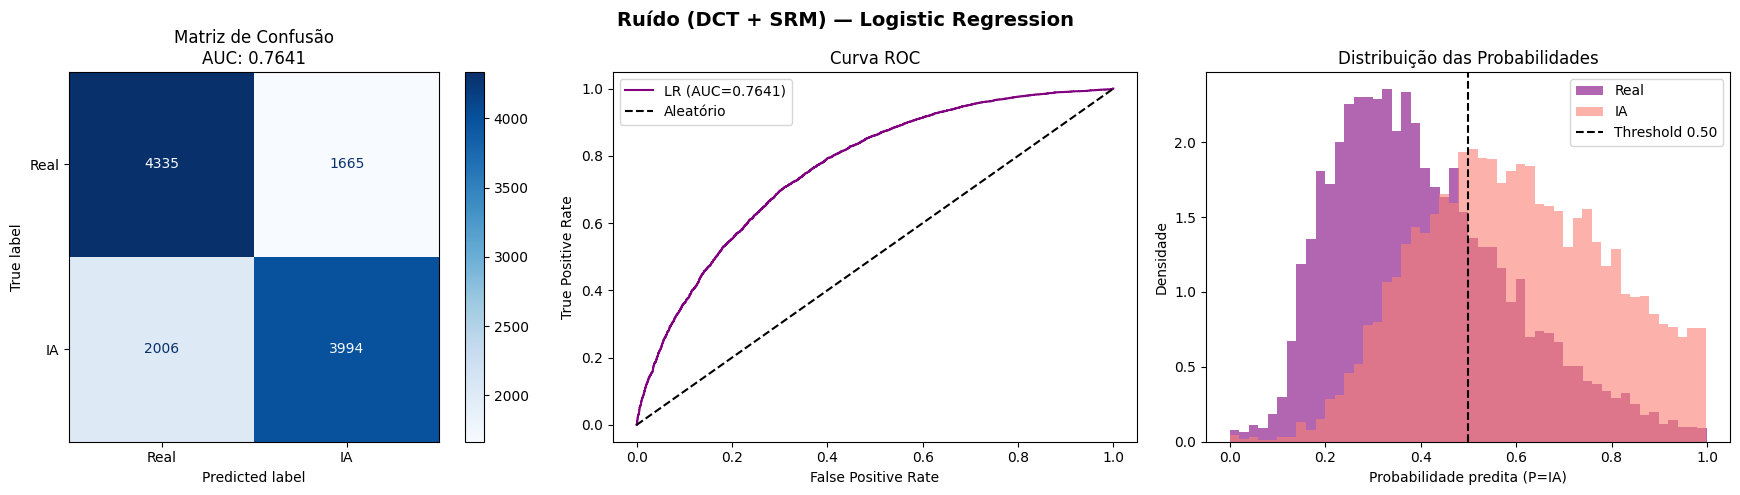


Modelo salvo: ..\..\modelos\Ruido\modelo_ruido_lr.pkl


In [7]:
# ─── BLOCO — Logistic Regression ─────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             precision_recall_curve, roc_curve)
import matplotlib.pyplot as plt

print("Treinando Logistic Regression...")
lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
lr.fit(X_train, y_train)
print("Concluído.\n")

# ── Avaliação ─────────────────────────────────────────────────────────────────
y_pred_lr  = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print("📊 Resultados Logistic Regression:")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"   F1       : {f1_score(y_test, y_pred_lr):.4f}")
print(f"   AUC-ROC  : {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"\n{classification_report(y_test, y_pred_lr, target_names=['Real', 'IA'])}")
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_lr))

# ── Threshold ótimo ───────────────────────────────────────────────────────────
prec, rec, thrs = precision_recall_curve(y_test, y_proba_lr)
f1_scores       = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_thr_lr     = float(thrs[np.argmax(f1_scores)])
y_pred_lr_thr   = (y_proba_lr >= best_thr_lr).astype(int)

print(f"\n📊 Com threshold ótimo ({best_thr_lr:.4f}):")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_lr_thr):.4f}")
print(f"   F1       : {f1_score(y_test, y_pred_lr_thr):.4f}")
print(classification_report(y_test, y_pred_lr_thr, target_names=['Real', 'IA']))

# ── Gráficos ──────────────────────────────────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ruído (DCT + SRM) — Logistic Regression', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm, display_labels=['Real', 'IA']).plot(
    ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title(f'Matriz de Confusão\nAUC: {roc_auc_score(y_test, y_proba_lr):.4f}')

fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
axes[1].plot(fpr, tpr, color='purple', label=f'LR (AUC={roc_auc_score(y_test, y_proba_lr):.4f})')
axes[1].plot([0,1],[0,1], 'k--', label='Aleatório')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC')
axes[1].legend()

axes[2].hist(y_proba_lr[y_test==0], bins=50, alpha=0.6, color='purple', label='Real', density=True)
axes[2].hist(y_proba_lr[y_test==1], bins=50, alpha=0.6, color='salmon', label='IA', density=True)
axes[2].axvline(0.5, color='black', linestyle='--', label='Threshold 0.50')
axes[2].set_xlabel('Probabilidade predita (P=IA)')
axes[2].set_ylabel('Densidade')
axes[2].set_title('Distribuição das Probabilidades')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'analise_lr.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Salvar ────────────────────────────────────────────────────────────────────
joblib.dump(lr, OUTPUT_DIR / 'modelo_ruido_lr.pkl')
print(f"\nModelo salvo: {OUTPUT_DIR / 'modelo_ruido_lr.pkl'}")

## Bloco 5 — Calibração e Threshold Ótimo

In [9]:
from sklearn.metrics import precision_recall_curve, accuracy_score, f1_score, roc_auc_score, classification_report
model = rf
# Sem calibração — usa probabilidades brutas do XGBoost
proba_cal = model.predict_proba(X_test)[:, 1]

prec, rec, thrs = precision_recall_curve(y_test, proba_cal)
f1_scores       = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_thr        = float(thrs[np.argmax(f1_scores)])
print(f'Threshold ótimo (F1): {best_thr:.4f}')

y_pred_cal = (proba_cal >= best_thr).astype(int)
print(f'\n📊 Resultados com threshold ótimo:')
print(f'   Accuracy : {accuracy_score(y_test, y_pred_cal):.4f}')
print(f'   F1       : {f1_score(y_test, y_pred_cal):.4f}')
print(f'   AUC-ROC  : {roc_auc_score(y_test, proba_cal):.4f}')
print(f'\n{classification_report(y_test, y_pred_cal, target_names=["Real", "IA"])}')

best   = model
metodo = 'sem calibração'

Threshold ótimo (F1): 0.4470

📊 Resultados com threshold ótimo:
   Accuracy : 0.7458
   F1       : 0.7706
   AUC-ROC  : 0.8339

              precision    recall  f1-score   support

        Real       0.81      0.64      0.72      6000
          IA       0.70      0.85      0.77      6000

    accuracy                           0.75     12000
   macro avg       0.76      0.75      0.74     12000
weighted avg       0.76      0.75      0.74     12000



[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 160 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed:    0.1s finished


## Bloco 6 — Análise de Resultados

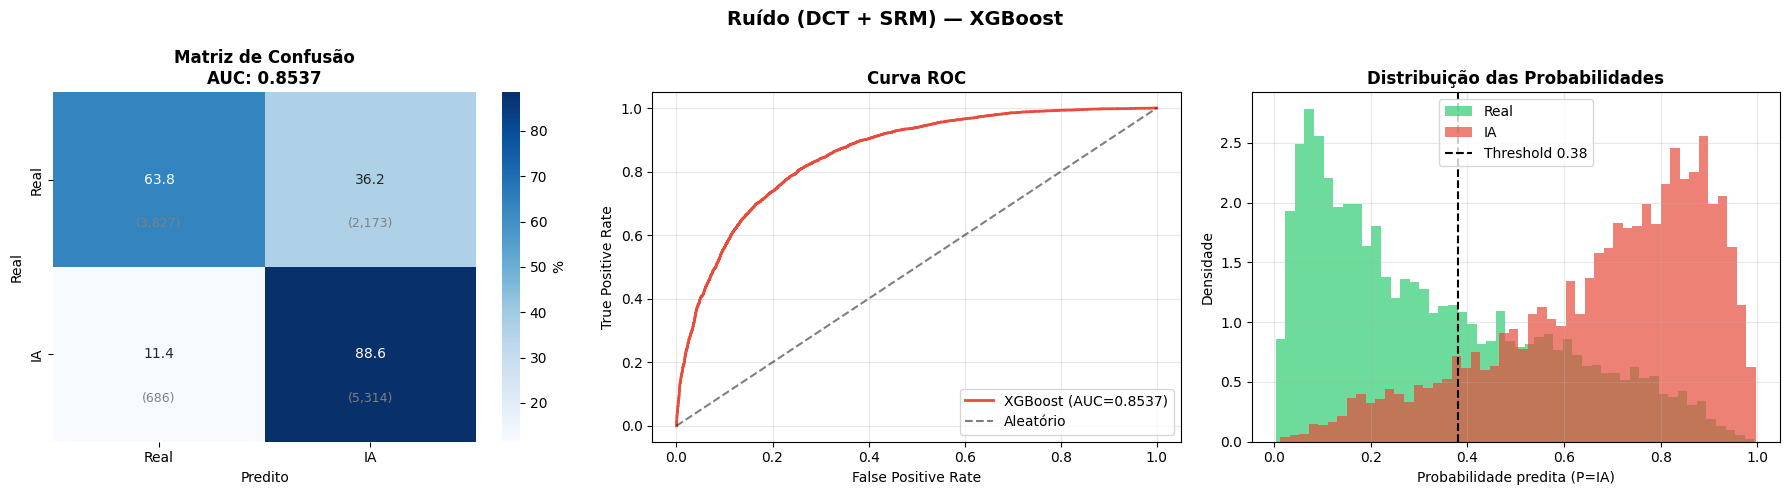


🔬 Análise de viés:
   Falsos Positivos (Real → IA): 2,173 (36.2%)
   Falsos Negativos (IA → Real): 686 (11.4%)
   Zona de incerteza (35%-65%): 26.7%


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matriz de confusão
cm     = confusion_matrix(y_test, y_pred_cal)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[0],
            xticklabels=['Real', 'IA'], yticklabels=['Real', 'IA'],
            cbar_kws={'label': '%'})
for i in range(2):
    for j in range(2):
        axes[0].text(j+0.5, i+0.75, f'({cm[i,j]:,})',
                     ha='center', va='center', fontsize=9, color='gray')
auc = roc_auc_score(y_test, proba_cal)
axes[0].set_title(f'Matriz de Confusão\nAUC: {auc:.4f}', fontweight='bold')
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predito')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, proba_cal)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'XGBoost (AUC={auc:.4f})')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.5, label='Aleatório')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Distribuição de probabilidades
axes[2].hist(proba_cal[y_test==0], bins=50, alpha=0.7, color='#2ecc71',
             label='Real', density=True)
axes[2].hist(proba_cal[y_test==1], bins=50, alpha=0.7, color='#e74c3c',
             label='IA', density=True)
axes[2].axvline(best_thr, color='black', linestyle='--', label=f'Threshold {best_thr:.2f}')
axes[2].set_xlabel('Probabilidade predita (P=IA)')
axes[2].set_ylabel('Densidade')
axes[2].set_title('Distribuição das Probabilidades', fontweight='bold')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Ruído (DCT + SRM) — XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CACHE_DIR / 'resultados_ruido.png', dpi=120, bbox_inches='tight')
plt.show()

# Análise de viés
fn = cm[0, 1]
fp = cm[1, 0]
print(f'\n🔬 Análise de viés:')
print(f'   Falsos Positivos (Real → IA): {fn:,} ({fn/cm[0].sum()*100:.1f}%)')
print(f'   Falsos Negativos (IA → Real): {fp:,} ({fp/cm[1].sum()*100:.1f}%)')
uncertain = ((proba_cal > 0.35) & (proba_cal < 0.65)).mean() * 100
print(f'   Zona de incerteza (35%-65%): {uncertain:.1f}%')

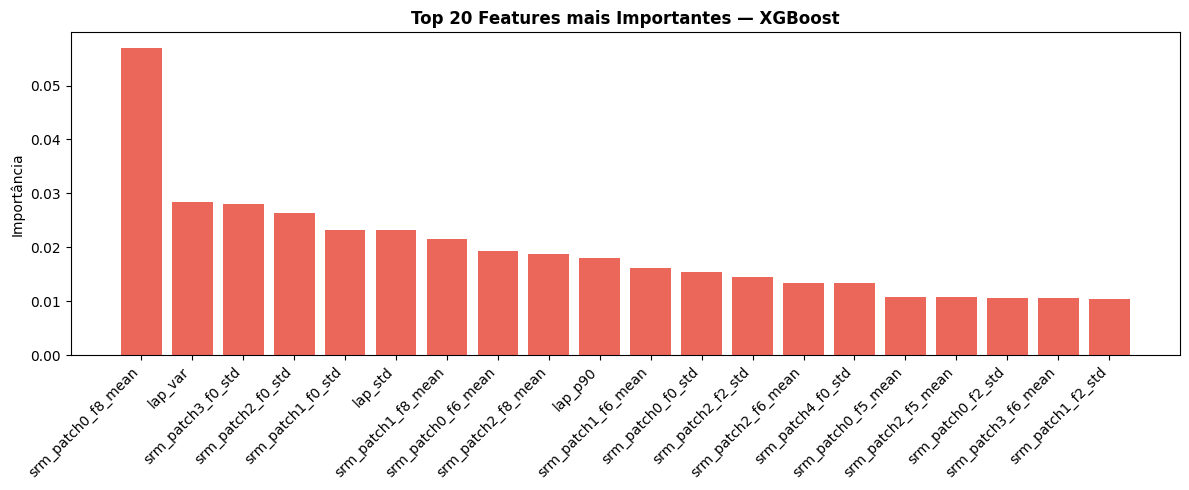


📋 Top 10 features:
    1. srm_patch0_f8_mean             → 5.70%
    2. lap_var                        → 2.83%
    3. srm_patch3_f0_std              → 2.80%
    4. srm_patch2_f0_std              → 2.64%
    5. srm_patch1_f0_std              → 2.32%
    6. lap_std                        → 2.32%
    7. srm_patch1_f8_mean             → 2.15%
    8. srm_patch0_f6_mean             → 1.93%
    9. srm_patch2_f8_mean             → 1.88%
   10. lap_p90                        → 1.80%


In [13]:
# Feature importance
feature_names = (
    [f'srm_patch{p}_f{f}_{s}'
     for p in range(6)
     for f in range(9)
     for s in ['mean', 'std']] +
    ['lap_var', 'lap_mean', 'lap_std', 'lap_p90']
)

importances = model.feature_importances_
top_idx     = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 5))
plt.bar(range(20), importances[top_idx], color='#e74c3c', alpha=0.85)
plt.xticks(range(20), [feature_names[i] for i in top_idx], rotation=45, ha='right')
plt.title('Top 20 Features mais Importantes — XGBoost', fontweight='bold')
plt.ylabel('Importância')
plt.tight_layout()
plt.savefig(CACHE_DIR / 'feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n📋 Top 10 features:')
for rank, idx in enumerate(top_idx[:10], 1):
    print(f'   {rank:2d}. {feature_names[idx]:30s} → {importances[idx]*100:.2f}%')

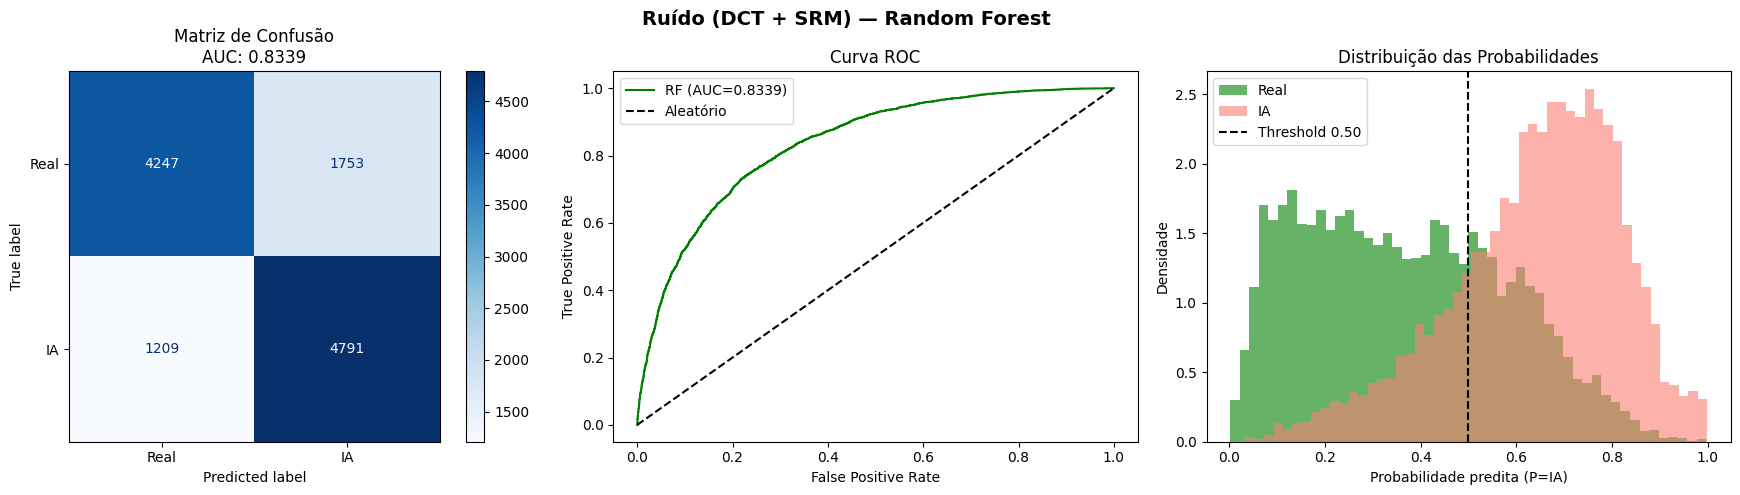

In [10]:
# ─── ANÁLISE — Random Forest ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ruído (DCT + SRM) — Random Forest', fontsize=14, fontweight='bold')

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm, display_labels=['Real', 'IA'])
disp.plot(ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title(f'Matriz de Confusão\nAUC: {roc_auc_score(y_test, y_proba_rf):.4f}')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
axes[1].plot(fpr, tpr, color='green', label=f'RF (AUC={roc_auc_score(y_test, y_proba_rf):.4f})')
axes[1].plot([0,1],[0,1], 'k--', label='Aleatório')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC')
axes[1].legend()

# Distribuição de probabilidades
axes[2].hist(y_proba_rf[y_test==0], bins=50, alpha=0.6, color='green', label='Real', density=True)
axes[2].hist(y_proba_rf[y_test==1], bins=50, alpha=0.6, color='salmon', label='IA', density=True)
axes[2].axvline(0.5, color='black', linestyle='--', label='Threshold 0.50')
axes[2].set_xlabel('Probabilidade predita (P=IA)')
axes[2].set_ylabel('Densidade')
axes[2].set_title('Distribuição das Probabilidades')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'analise_rf.png', dpi=150, bbox_inches='tight')
plt.show()

## Bloco 7 — Salvar Modelo

In [14]:
joblib.dump(best, OUTPUT_DIR / 'modelo_ruido.pkl')
with open(OUTPUT_DIR / 'threshold.json', 'w') as f:
    json.dump({'threshold': best_thr, 'metodo': metodo}, f, indent=2)

print('💾 Modelos salvos:')
print(f'   {OUTPUT_DIR / "modelo_ruido.pkl"}')
print(f'   {OUTPUT_DIR / "threshold.json"}')
print(f'\n✅ Threshold: {best_thr:.4f} | Calibração: {metodo}')

💾 Modelos salvos:
   ..\..\modelos\Ruido\modelo_ruido.pkl
   ..\..\modelos\Ruido\threshold.json

✅ Threshold: 0.3808 | Calibração: sem calibração
